# 🛒 DID 独立练习：电商大促对 GMV 的因果评估

## 你的目标
**不看之前的 Notebook**，仅参考速查手册，独立完成 DID + Event Study 全流程。

## 业务场景
某电商平台在 **2024 年 6 月 (Week 5)** 针对部分城市上线了 "满 200 减 50" 大促活动。
你需要评估这次大促对 **GMV (Gross Merchandise Value)** 的因果效应。

| 维度 | 设定 |
| :--- | :--- |
| 城市数 | 8 个 (4 处理 + 4 对照) |
| 时间范围 | 10 周 (Week 1-10) |
| 干预时间 | Week 5 开始 |
| 因变量 | GMV (万元) |
| 真实效应 | 50 万元 |

---

## Step 0: 导入库 + 设定参数 ✅ (已填写)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pyfixest as pf

# ========== 实验参数 ==========
NUM_CITIES = 8            # 城市总数
NUM_TREATED = 4           # 处理组城市数
NUM_WEEKS = 10            # 时间跨度 (周)
TREATMENT_START = 5       # 干预开始的周 (Week 5)
TRUE_ATE = 50             # 真实因果效应 (万元)
NOISE_STD = 15            # 随机噪声标准差
RANDOM_SEED = 42          # 随机种子 (可复现)

np.random.seed(RANDOM_SEED)

# 中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print('✅ 库导入完成，参数设定完成')
print(f'真实 ATE = {TRUE_ATE} 万元，干预从 Week {TREATMENT_START} 开始')

✅ 库导入完成，参数设定完成
真实 ATE = 50 万元，干预从 Week 5 开始


## Step 1: 模拟面板数据 ✅ (已填写)

🤔 **思考题**: 看懂下面的代码后想想——为什么不能让所有城市的 base GMV 一样？

In [3]:
# 每个城市的基础 GMV (模拟城市间的固有差异)
city_base_gmv = {
    0: 200, 1: 250, 2: 180, 3: 220,  # 对照组城市
    4: 210, 5: 240, 6: 190, 7: 230,  # 处理组城市
}

# 自然增长趋势 (每周增长 5 万元)
WEEKLY_GROWTH = 5

# 构造面板数据
rows = []
for city in range(NUM_CITIES):
    is_treated = 1 if city >= NUM_TREATED else 0  # 城市 4-7 是处理组
    for week in range(1, NUM_WEEKS + 1):
        is_post = 1 if week >= TREATMENT_START else 0
        
        # GMV = 城市基础值 + 自然增长 + 噪声
        gmv = city_base_gmv[city] + WEEKLY_GROWTH * week + np.random.normal(0, NOISE_STD)
        
        # 处理组在干预后加上真实效应
        if is_treated and is_post:
            gmv += TRUE_ATE
        
        rows.append({
            'city': city,
            'week': week,
            'is_treated': is_treated,
            'is_post': is_post,
            'gmv': round(gmv, 1)
        })

df = pd.DataFrame(rows)

print(f'✅ 面板数据构造完成: {df.shape[0]} 行 × {df.shape[1]} 列')
print(f'处理组城市: {df[df["is_treated"]==1]["city"].unique()}')
print(f'对照组城市: {df[df["is_treated"]==0]["city"].unique()}')
df.head(12)

✅ 面板数据构造完成: 80 行 × 5 列
处理组城市: [4 5 6 7]
对照组城市: [0 1 2 3]


,city,week,is_treated,is_post,gmv
0,0,1,0,0,212.5
1,0,2,0,0,207.9
2,0,3,0,0,224.7
3,0,4,0,0,242.8
4,0,5,0,1,221.5
5,0,6,0,1,226.5
6,0,7,0,1,258.7
7,0,8,0,1,251.5
8,0,9,0,1,238.0
9,0,10,0,1,258.1


---

## 🎯 从这里开始，全部由你自己写！

---

## Step 2: 数据探索 (EDA)

💡 **提示**:
- `df.head()` / `df.shape` / `df.describe()`
- 画折线图: 按 `is_treated` 分组，看 GMV 随 week 的变化
- 标出干预时间线

In [4]:
# ✏️ 你的代码
print(df.shape)
display(df.head())
display(df.describe(include='all'))

(80, 5)


,city,week,is_treated,is_post,gmv
0,0,1,0,0,212.5
1,0,2,0,0,207.9
2,0,3,0,0,224.7
3,0,4,0,0,242.8
4,0,5,0,1,221.5


,city,week,is_treated,is_post,gmv
count,80.000000,80.000000,80.000000,80.000000,80.000000
mean,3.500000,5.500000,0.500000,0.600000,255.643750
std,2.305744,2.890403,0.503155,0.492989,41.539406
min,0.000000,1.000000,0.000000,0.000000,178.600000
25%,1.750000,3.000000,0.000000,0.000000,225.300000
50%,3.500000,5.500000,0.500000,1.000000,252.250000
75%,5.250000,8.000000,1.000000,1.000000,280.575000
max,7.000000,10.000000,1.000000,1.000000,354.600000


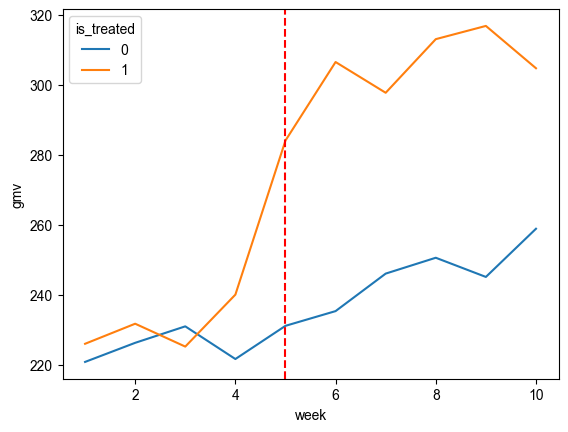

In [8]:
t_group = df.groupby(['week','is_treated'])['gmv'].mean().reset_index()
t_group




sns.lineplot(data=t_group,x='week',y='gmv',hue='is_treated',err_style='bars')
plt.axvline(x=5,color = 'red',linestyle='--',label = '实验开始周期')




## Step 3: 平行趋势检验 ⚠️ 核心

💡 **提示**: 速查手册有三层递进的检验方法 (L1 可视化 → L2 分组斜率 → L3 交互项)

🤔 **思考题**: 如果平行趋势检验不通过 (P < 0.05)，你接下来应该怎么做？

In [10]:
df_pre = df[df['week']<5]

slopes = []
for is_treated in [0,1]:
    model_pre = smf.ols("gmv ~ week",data=df_pre[df_pre['is_treated']==is_treated]).fit()
    slopes.append({
        'is_treated':'control' if 'is_treated'==0 else 'treated',
        'slope':model_pre.params['week'],
        'pvalue':model_pre.pvalues['week'],
        'r2':model_pre.rsquared
    })
    
print(pd.DataFrame(slopes))

  is_treated   slope    pvalue        r2
0    treated  0.7175  0.907427  0.001000
1    treated  3.5550  0.588734  0.021405


In [12]:
model_paralle = smf.ols("gmv ~ week * is_treated",data=df_pre).fit()
interaction_p = model_paralle.pvalues['week:is_treated']
print(f'p值为{interaction_p:.4f}')
print(f'结论:{'平行趋势成立' if interaction_p > 0.05 else '平行趋势不成立'}')

p值为0.7504
结论:平行趋势成立


## Step 4: 经典 DID 回归

💡 **提示**:
- 公式: `gmv ~ is_treated * is_post`
- 用 `statsmodels` 的 `smf.ols()`
- 解读 4 个系数的业务含义 (Intercept, is_treated, is_post, is_treated:is_post)

🤔 **思考题**: `is_treated:is_post` 的系数和你设定的 TRUE_ATE (50) 接近吗？如果偏差很大，可能是什么原因？

In [ ]:
# ✏️ 你的代码
model= smf.ols("gmv~is_treated*is_post",data=df).fit()
print(model.summary())
# 结论: ATE to gmv by post * treated = 53.4188 万元 

                            OLS Regression Results                            
Dep. Variable:                    gmv   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     40.00
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           1.28e-15
Time:                        18:38:22   Log-Likelihood:                -373.25
No. Observations:                  80   AIC:                             754.5
Df Residuals:                      76   BIC:                             764.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            224.9813      6

## Step 5: Event Study (动态因果效应) 🌟 重点

### 5a. 手写版 (statsmodels)

💡 **提示**:
- 先构造 `week_relative` 列 (以干预前最后一期为基准 = 0)
- 对每一期跑 `is_treated` 的交互项
- 提取交互项系数 → 画 errorbar 图

🤔 **思考题**: 基准期 (reference period) 的效应为什么必须设为 0？如果选错基准期会怎样？

Text(0.5, 1.0, 'event study:动态因果效应')

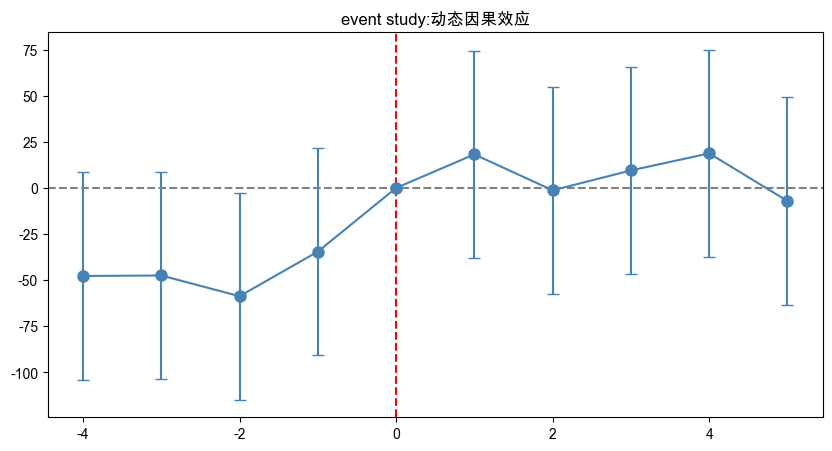

In [18]:
# ✏️ 你的代码 (手写 Event Study)
# 实验开始时间 week = 5 
reference_week = 5 
# 相对week
df['week_relative'] = df['week'] - reference_week
model_event = smf.ols("gmv ~ is_treated * C(week_relative,Treatment(0))",data=df).fit()

event_study_results = []
for param_name,coef in model_event.params.items():
    if "is_treated:C(week_relative" in param_name:
        week_num = int(float(param_name.split('[T.')[1].rstrip(']')))
        ci = model_event.conf_int().loc[param_name]
        event_study_results.append({
            "week_relative":week_num,
            "effect":coef,
            "ci_lower":ci[0],
            "ci_upper":ci[1],
            'p_value':model_event.pvalues[param_name]
        })

event_study_results.append({
    'week_relative':0,
    'effect':0,'ci_lower':0,'ci_upper':0,'p_value':1.0})

es_df = pd.DataFrame(event_study_results).sort_values('week_relative')

plt.figure(figsize=(10,5))
plt.errorbar(es_df['week_relative'],es_df['effect'],yerr=[es_df['effect']-es_df['ci_lower'],es_df['ci_upper'] - es_df['effect']],
    fmt = 'o-',capsize = 4,color = 'steelblue',markersize=8)
plt.axhline(y=0,color='gray',ls='--')
plt.axvline(x=0,color='red',ls='--',label='干预开始')
plt.title('event study:动态因果效应')






### 5b. pyfixest 版 (3 行搞定)

💡 **提示**: 
- `pf.feols()` + `pf.iplot()`
- 语法: `"gmv ~ i(week_relative, is_treated, ref=0) | city"`

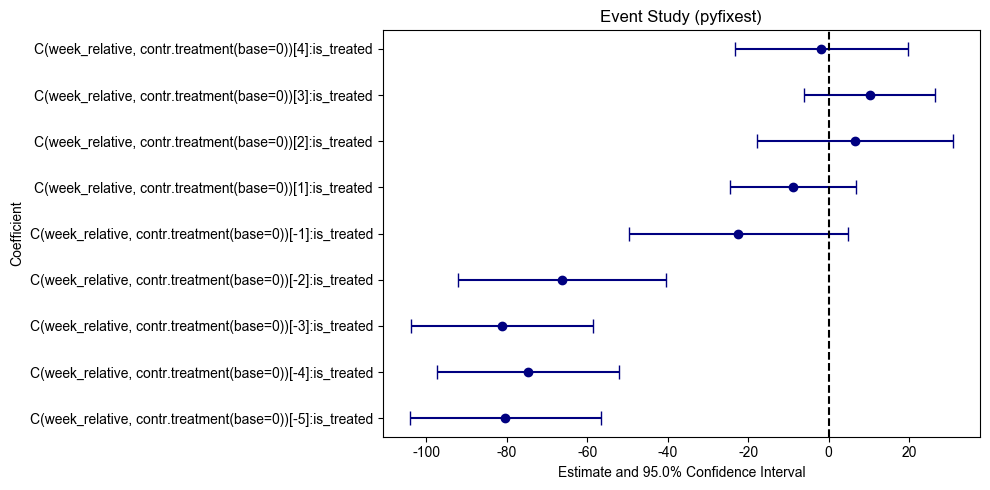

In [20]:
# ✏️ 你的代码 (pyfixest 一行建模)

import pyfixest as pf

# 1. 构造相对时间
df['week_relative'] = df['week'] - 6  # 基准期

# 2. 一行建模
# i(week_relative, is_treated, ref=0): 自动交互项，0 为基准
# | city: 城市固定效应
fit = pf.feols(
    "gmv ~ i(week_relative, is_treated, ref=0) | city",
    data=df,
    vcov={'CRV1': 'city'}  # 按城市聚类标准误
)

# 3. 一行画图
pf.iplot(fit, figsize=(10, 5),
         title='Event Study (pyfixest)')

## Step 6: 稳健性检验 (Placebo Test)

💡 **提示**: 做两种安慰剂检验
- **假时间**: 假装干预提前了 (比如 Week 3 就开始)，效应应该接近 0
- **假处理**: 随机打乱 `is_treated` 标签，效应应该接近 0

🤔 **思考题**: 如果 Placebo Test 也显著了 (P < 0.05)，说明什么问题？

In [ ]:
# ✏️ 你的代码



## Step 7: 结论与业务汇报

💡 **提示**: 用速查手册 §2.4 的业务汇报模板，写一段给老板看的结论

用 Markdown 写出:
1. 一句话结论 (包含具体数字)
2. 为什么可以相信这个结论 (平行趋势 + Placebo)
3. 局限性与建议

### ✏️ 你的业务汇报

> [在这里写你的结论]


---

## 🏁 完成后自检清单

- [ ] 数据模拟：运行 Step 0 + Step 1 成功
- [ ] EDA：画出了分组折线图 + 干预时间线
- [ ] 平行趋势检验通过 (至少做了 L1 可视化)
- [ ] DID 回归系数接近 TRUE_ATE (50)
- [ ] Event Study 图: Pre 接近 0, Post 显著为正
- [ ] pyfixest 一行建模成功
- [ ] Placebo Test 不显著
- [ ] 写了业务汇报结论

**如果以上全部打勾 ✅，恭喜你已经掌握了 DID 的核心！**